# Homework08

Some exercises with text files and string manipulation

## Goals

- Get familiar with how strings work in Python
- Practice processing text files

## Import helpers

Run the following cell to import helper functions, files and libraries

In [1]:
from string import ascii_lowercase
from Homework08_utils import Homework08_utils

## A little review

Before we get into the deep of the exercises, just a little review about strings and/as lists.

Strings are like lists. Most of the functions we use on lists (`len()`, `sorted()`, `reversed()`, etc) work on strings. And indexing (positive and negative) as well as slicing, work the same.

We can concatenate strings and append to strings using $+$:

```py
# concatenate
my_str = "it was the" + " best thing"

# append
my_str += " ever"
```

<br><br>Some operations or processing of strings might end up giving us a list of characters in the end (`reversed()` and `sorted()`, for example).

```py
print(sorted("once upon"))
>>> [' ', 'c', 'e', 'n', 'n', 'o', 'o', 'p', 'u']
```

<br><br>In these cases, we can turn the list of characters back into a string with `join()`, but the syntax is a little less intuitive than most Python functions and feels backwards:

```py
"".join(list_of_characters)
```

<br><br>It's like this because you can use it to add any separator between items of anything that is _iterable_:
```py
", ".join(["apple", "pineapple", "banana", "pen"])
```

<br><br>Turning a string into a list of characters is easy and intuitive:
```py
list("once upon a time")
```

### TL;DR

##### string to list of characters: `list(string_variable)`

##### list of characters to string: `"".join(char_list)`

## Secrets

We've discovered some secret messages left by a mathematician inside a book.

We can see all of the messages here: `Homework08_utils.MSGS`, but there's some strong evidence that suggests that they are connected and that decoding the first one will help decode the second one and so on...

### Secret 0

Let's look at the first message:

In [2]:
print(Homework08_utils.MSGS[0])

uif ofyu nfttbhf xbt fodpefe vtjoh uif tbnf tusbufhz bt uijt pof, cvu xjui b mbshfs tijgu bnpvou.
uifsf bsf pomz 26 qpttjcjmjujft, tp ... nbzcf bo bvupnbujd xbz pg uszjoh bmm qpttjcjmjujft xpvme ifmq ...


#### _Cesar Cipher_

A team of code breakers and cryptographers has suggested that we start by trying to decode the message using a [_Cesar Cipher_](https://en.wikipedia.org/wiki/Caesar_cipher) transformation.

This is a simple form of encoding/decoding where the characters are just shifted by a predetermined amount, but their relative order stays the same.

So, if the letter `D` has been encoded as `A`, the letter `E` will be `B`, and so on.

<div style="padding:30px 20px; background-color:#fff; display:block; width:600px;" >
  <img src="./imgs/caesar-cipher.png" width=600>
</div>

Let's try it out with a shift of $1$. Write some code that iterates over the message and decodes the letters by shifting them back by $1$ position: the letter `u` becomes `t`, `i` becomes `h`, `f` becomes `e`, etc ...

#### Practical Cesar

We have imported the `ascii_lowercase` member variable from the `string` library. This variable holds all of the lowercase letters of the roman alphabet in order, as a string: `abcdefghijklmnopqrstuvwxyz`.

This means we can get a letter at a specific location by indexing into this string with `[ ]`, and, conversely,  we can find the index of a letter by using the `index()` function:

```py
ascii_lowercase[7]
>>> "i"

ascii_lowercase[-1]
>>> "z"

ascii_lowercase.index("a")
>>> 0

ascii_lowercase.index("b")
>>> 1
```

In [13]:
# TODO: decode the first message assuming it was created using a Cesar cipher of 1
# TODO: characters not in ascii_lowercase stay the same and don't have to be decoded

msg0 = Homework08_utils.MSGS[0]
decoded0 = ""

for char in msg0:
    if char in ascii_lowercase:
        idx = ascii_lowercase.index(char)
        decoded0 += ascii_lowercase[(idx - 1) % 26]
    else:
        decoded0 += char

print(decoded0)

the next message was encoded using the same strategy as this one, but with a larger shift amount.
there are only 26 possibilities, so ... maybe an automatic way of trying all possibilities would help ...


### Secret 1

Ok. A hint !

Let's look at the message:

In [4]:
print(Homework08_utils.MSGS[1])

ylhk aol khah/hzayvshil.aea mpsl. thrl pa svdly jhzl. jvbua slaaly mylxblujf.
bzl aol vykly av kljvkl aol ulea alea:
aol tvza mylxblua slaaly pu aol zljyla tlzzhnl jvyylzwvukz av aol tvza mylxblua slaaly pu aol alea mpsl,
aol zljvuk tvza mylxblua slaaly pu aol zljyla pz aol zljvuk tvza mylxblua slaaly pu aol alea mpsl,
huk zv vu...


#### Funct-ify it

It could help if we wrapped the code we used above inside a function that takes the shift amount as a parameter.

In [14]:
# TODO: turn the code from above into a function that takes a parameter for the amount of un-shifting

def uncesar(txt, amt):
    msg = ""
    for char in txt:
        if char in ascii_lowercase:
            idx = ascii_lowercase.index(char)
            msg += ascii_lowercase[(idx - amt) % 26]
        else:
            msg += char
    return msg

In [17]:
print(uncesar(Homework08_utils.MSGS[1], 7))

read the data/astrolabe.txt file. make it lower case. count letter frequency.
use the order to decode the next text:
the most frequent letter in the secret message corresponds to the most frequent letter in the text file,
the second most frequent letter in the secret is the second most frequent letter in the text file,
and so on...


#### Test it on the first message with a shift of $1$

In [19]:
print(uncesar(Homework08_utils.MSGS[0], 1))

the next message was encoded using the same strategy as this one, but with a larger shift amount.
there are only 26 possibilities, so ... maybe an automatic way of trying all possibilities would help ...


#### Loop time

Test all possible $25$ shifts and see which one (if any) produces a legible message.

(it's $25$ because we know it's not a shift of $0$, and a shift of $26$ wraps around and is the same as a shift of $0$)

In [20]:
# TODO: use the function on the encrypted message until we get something that looks decrypted.
for i in range(1, 26):
    result = uncesar(Homework08_utils.MSGS[1], i)
    print(f"Shift {i}: {result[:60]}")

Shift 1: xkgj znk jgzg/gyzxurghk.zdz lork. sgqk oz ruckx igyk. iuatz 
Shift 2: wjfi ymj ifyf/fxywtqfgj.ycy knqj. rfpj ny qtbjw hfxj. htzsy 
Shift 3: vieh xli hexe/ewxvspefi.xbx jmpi. qeoi mx psaiv gewi. gsyrx 
Shift 4: uhdg wkh gdwd/dvwurodeh.waw iloh. pdnh lw orzhu fdvh. frxqw 
Shift 5: tgcf vjg fcvc/cuvtqncdg.vzv hkng. ocmg kv nqygt ecug. eqwpv 
Shift 6: sfbe uif ebub/btuspmbcf.uyu gjmf. nblf ju mpxfs dbtf. dpvou 
Shift 7: read the data/astrolabe.txt file. make it lower case. count 
Shift 8: qdzc sgd czsz/zrsqnkzad.sws ehkd. lzjd hs knvdq bzrd. bntms 
Shift 9: pcyb rfc byry/yqrpmjyzc.rvr dgjc. kyic gr jmucp ayqc. amslr 
Shift 10: obxa qeb axqx/xpqolixyb.quq cfib. jxhb fq iltbo zxpb. zlrkq 
Shift 11: nawz pda zwpw/wopnkhwxa.ptp beha. iwga ep hksan ywoa. ykqjp 
Shift 12: mzvy ocz yvov/vnomjgvwz.oso adgz. hvfz do gjrzm xvnz. xjpio 
Shift 13: lyux nby xunu/umnlifuvy.nrn zcfy. guey cn fiqyl wumy. wiohn 
Shift 14: kxtw max wtmt/tlmkhetux.mqm ybex. ftdx bm ehpxk vtlx. vhngm 
Shift 15: jwsv 

### Secret 2

## 🎉
Another hint !

Let's look at the next message:

In [21]:
print(Homework08_utils.MSGS[2])

ap awizs, pi wstio. brkksj dahhsgjp ortt sxsgvs trus a psfgsh xstiky.
obah pssxsk fbaihrf ortt gszsat rhp gbyhbx, vmrkrjv yimg ksfrprijp orhb ftagrhy.
day ahhsjhrij hi pmwhts prvjatp ap hbsy faggy hbs hgmhb wsjsahb hbs pmgeafs.
<|rxavs|>
...
<|rxavs|>
<|sjk ie xsppavs | rvjigs aehsg hbrp|>
wldaissrrbxgauyijjvnhbcbyincmtgbezsjbebjmsahtsaxokxejvpxpesdkhspsfghibdilpmncapghswtxuqfwbmrxbdpuamssphvmqtjeajctlffpstbtbhwisfbhkddjnafxdpwtqjorigyhspicyszdijyafcgixkzsrmgpakkrrpugokasgashijpwsnap sappxfcsahhtnnafpwlrfzpwlfiqzcnthxxhbkvypqmlthmgtpqjmjfckpcecrghmrgxjqtajejahsxypjfchqjstgdghwazjbcchsuvekfrdnmibqphgcialtcewjitiziarhyibipiwttsxjorsrheooshvshryokaunwpbitfskasjdtigelqwgtmfgjcziissjwrqsbsprhsntzqbnbcaiihtjesamsylgiyrigibcsgocruthuimagmbjajsiqyjkrfhmhsmavlthghlcyuaayrmpytfhjmfhzxurhphptdhpdxiitnofnhhzbraxmpqtasgfhffttohrkzxtobafjwrvrytxbtdeajhjwzhcbsbqxvghtssjsdzqkkrhxyfhnwofworbprkamdbbvdanpsjvhcmhijpfimtrhjsohsppwrsarrabirjvebohzswsekhpskprjbeqsrpdbjgsrtdafhfwoeebobsftftimlkgpjtitwzjfiapg

## 🤦

At least we have a hint.

Let's start by opening up the file, turning everything into lowercase, and counting the occurrence of each letter.

We'll do the same for the encoded text. Maybe a function will help... but since it's just $2$ texts we can do it without a function too.

A dictionary can help keep track of letter counts:
```py
counts = {
  "a": 0,
  "b": 12,
  ...
}
```

Or, we can use a list of lists, initially ordered by alphabetical order:
```py
counts = [ ["a", 0], ["b", 12], ... ]
```

If something is not in `ascii_lowercase` we'll just skip it.

In [23]:
# TODO: count occurrences in the source text file and in the encoded message
with open("data/astrolabe.txt", "r") as f:
    text_content = f.read().lower()

text_counts = {}
for char in text_content:
    if char in ascii_lowercase:
        text_counts[char] = text_counts.get(char, 0) + 1

# Count letters in the encoded secret message
secret_msg = Homework08_utils.MSGS[2]
secret_counts = {}
for char in secret_msg:
    if char in ascii_lowercase:
        secret_counts[char] = secret_counts.get(char, 0) + 1

#### Sort the letters by occurrence

Either most to least frequent or least to most. We just have to be consistent.

If a dictionary was used in the previous step, we have to turn it into a list of `[letter, count]` pairs before sorting it:
```py
letter_count_list = []
for ltr,cnt in letter_count_dict.items():
  letter_count_list.append([ltr,cnt])
```

And sorting can then be done with a key function that looks at the second term of each `[letter, count]` pair:
```py
def byCount(LC):
  ltr,cnt = LC
  return cnt
  # OR
  return LC[1]
```

After sorting them, we can get rid of the counts and keep just $2$ lists of letters, one for the source file and one for the secret message.

In [24]:
# TODO: sort the letters by occurrence
# TODO: discard the counts, and only keep the letters
text_sorted   = sorted(text_counts.items(),   key=lambda lc: lc[1])
secret_sorted = sorted(secret_counts.items(), key=lambda lc: lc[1])

# Keep only the letters (discard the counts)
text_order   = [lc[0] for lc in text_sorted]
secret_order = [lc[0] for lc in secret_sorted]

#### Create a decoder

We have two ordered lists of letters, and we want to be able to use the relative order of the letters in both lists to perform a type of letter replacement. 

So, every time we see `t` in the encoded message, we'll look up the index of `t` in the list of letters from the encoded message, and then use this index to get the replacement letter in the ordered list of letters from the text file we read.

Something like:
```py
text_order[secret_order.index(L)]
```

And, as always, we'll skip characters that are not in the `ascii_lowercase` list.

In [26]:
# TODO: decode message by using the index of each letter in one list to get a letter from second list
decoded_msg = ""
for char in secret_msg:
    if char in ascii_lowercase and char in secret_order:
        decoded_msg += text_order[secret_order.index(char)]
    else:
        decoded_msg += char

print(decoded_msg)

as above, so below. hidden patterns will emerge like a secret melody.
what seemed chaotic will reveal its rhythm, guiding your decisions with clarity.
pay attention to subtle signals as they carry the truth beneath the surface.
<|image|>
...
<|image|>
<|end of message | ignore after this|>
bzpaoeeiihmrakyonngqthxhyoqxulrhfvenhfhnueatleamwdmfngsmsfepdtesecrtohpozsuqxasrteblmkjcbhuimhpskaueestgujlnfanxlzccselhlhtboechtdppnqacmpsbljnwiorytesoxyevponyacxromdveiursaddiiskrwdaeraetonsbeqas eassmcxeattlqqacsbzicvsbzcojvxqltmmthdgysjuzlturlsjnuncxdsxfxirtuirmnjlanfnatemysncxtjnelrprtbavnhxxtekgfdcipquohjstrxoazlxfbnolovoaityohosobllemnwieitfwwetgetiywdakqbsholcedaenplorfzjbrlucrnxvooeenbijehesiteqlvjhqhxaootlnfeaueyzroyiorohxerwxikltkouaruhnaneojyndictuteuagzltrtzxykaayiusylctnuctvmkitstslptspmoolqwcqttvhiamusjlaerctccllwtidvmlwhacnbigiylmhlpfantnbvtxhehjmgrtleenepvjdditmyctqbwcbwihsidauphhgpaqsengtxutonscoulitnewtessbieaiiahoingfhwtvebefdtsedsinhfjeisphnreilpactcbwffhwheclclouzdrsnlolbvncoasr

## 🎉
Hooray ! Message decoded !

### Bonus

There are some funny looking characters at the end of the message.

They were added in order to ensure the letter occurrences in the message matched the letter occurrences of the plain text file.

But... there is a special portion of the decoded text, sandwiched between `<|image|>` separators, that IS part of the message.

This looks like the [$\text{Base}64$](https://en.wikipedia.org/wiki/Base64) encoding we saw in `Homework07`, but it's actually [$\text{Base}32$](https://en.wikipedia.org/wiki/Base32), which is the same, but doesn't differentiate between upper and lower case letters.

Let's `split()` the decoded message and extract this special string and pass it onto the `Homework08_utils.b32_to_img()` function to see if we get anything.

$\textbf{NOTE}$: we only want to pass the characters in between the `<|image|>` separators, but WITHOUT the separators.

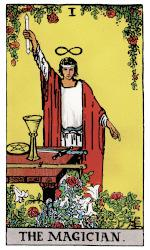

In [27]:
# TODO: split decoded message and extract text between <|image|> tags
parts = decoded_msg.split("<|image|>")
b32_str = parts[1].strip()

Homework08_utils.b32_to_img(b32_str)

# 🪄⚡️